# Type C — Funded-Continuation Surplus Hedge

**Hedge Type:** You hedge through the challenge, get funded, keep hedging, and deliberately **oversize** the funded hedge so that a failure event doesn't just recover costs — it produces **surplus profit**.

**Goal:** Even when the prop side loses, that loss becomes a monetisable outcome.

## EV Formula

$$\text{EV}_C = \text{funded withdrawals} + \text{surplus on failure} - \text{all hedge drag}$$

## Hedge Sizing

**Type B (recovery only):** $S = \dfrac{L}{DD}$

**Type C (recovery + surplus):** $S = \dfrac{L + P}{DD}$

Where $P$ = desired surplus profit on failure.

## Key Question

> "Can I build the hedge so that even when the prop side loses, that loss event becomes a monetisable outcome rather than just a recovery event?"

## Worked Example

| Metric | Value |
|--------|-------|
| Insured stack at funded | $1,500 |
| Desired surplus | $500 |
| Hedge sized for | $2,000 (L + P) |
| Funded withdrawals | $2,200 |
| Hedge drag | $900 |
| Failure recovery | $1,500 (stack) + $500 (surplus) |
| **EV_C** | **$2,200 + $500 − $900 = $1,800** |

---

**Reference:** [hedging-explained.md](../Product/hedging-explained.md) §5 Type C

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

exec_path = os.path.join(STRATEGY_ROOT, "executions")
if exec_path not in sys.path:
    sys.path.insert(0, exec_path)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET = 0.08     # 8% funded target (challenge phase)
SPREAD_COST   = 0.0003   # 3 pips per side
RESIZES_PER_PHASE = 20

# ── Type C funded-phase assumptions ──
FUNDED_WITHDRAWAL_PCT = 0.04   # 4% withdrawal per cycle
FUNDED_CYCLES = 6              # cycles modelled
FUNDED_SURVIVAL_RATE = 0.80    # survival prob per cycle
FUNDED_HEDGE_DRAG_PCT = 0.015  # hedge drag per cycle (% of account)
SURPLUS_TARGET_PCT = 0.02      # desired surplus = 2% of account size on failure

print("Type C notebook ready.")
print(f"Challenge: funded_target={FUNDED_TARGET*100:.0f}%, spread={SPREAD_COST}")
print(f"Funded: withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
      f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, "
      f"drag={FUNDED_HEDGE_DRAG_PCT*100:.1f}%/cycle")
print(f"Surplus target: {SURPLUS_TARGET_PCT*100:.1f}% of account on failure")

Type C notebook ready.
Challenge: funded_target=8%, spread=0.0003
Funded: withdrawal=4.0%/cycle, survival=80%/cycle, drag=1.5%/cycle
Surplus target: 2.0% of account on failure


## 1 — Load Data

In [2]:
json_files = glob.glob(os.path.join(DATA_DIR, "propmatch_challenges_*.json"))
if not json_files:
    raise FileNotFoundError("No scraped data.")

latest = max(json_files, key=os.path.getmtime)
print(f"Loading: {os.path.basename(latest)}")

with open(latest, 'r', encoding='utf-8') as f:
    raw = json.load(f)

challenges = raw.get("challenges", raw if isinstance(raw, list) else [])
print(f"Loaded {len(challenges)} challenges")

def classify_drawdown(dd_type_str):
    if not dd_type_str or dd_type_str == "-":
        return "static"
    if "trailing" in dd_type_str.lower():
        return "trailing"
    return "static"

Loading: propmatch_challenges_20260324_183523.json
Loaded 224 challenges


## 2 — Type C Model: Challenge Phase + Surplus Continuation

### How Type C extends Type B

Type B sizes the funded hedge for **recovery only** ($S = L / DD$).

Type C sizes for **recovery + surplus** ($S = (L + P) / DD$).

The oversized hedge means:
- More drag per cycle (bigger hedge = more loss when funded account profits)
- But failure produces surplus profit, not just stack recovery

### The tradeoff

| | Type B | Type C |
|---|---|---|
| Hedge sizing | $L / DD$ | $(L + P) / DD$ |
| Drag per cycle | Lower | Higher |
| Failure outcome | Recovers costs | Recovers costs + surplus |
| Capital required | Lower | Higher |
| Complexity | Moderate | Higher |

In [3]:
def compute_type_a_cost(challenge, funded_target_pct=FUNDED_TARGET,
                        spread_cost_pct=SPREAD_COST,
                        resizes_per_phase=RESIZES_PER_PHASE):
    """Challenge-phase cost stack (Type A baseline)."""
    S = challenge.get("account_size", 0)
    fee = challenge.get("fee_assumed") or challenge.get("fee_original") or challenge.get("fee_discounted") or 0
    targets = challenge.get("profit_targets") or []
    steps = challenge.get("steps") or len(targets) or 2
    dd_max_pct = (challenge.get("max_drawdown_pct") or 10.0) / 100.0
    split = (challenge.get("profit_split_pct") or 80.0) / 100.0
    dd_category = classify_drawdown(challenge.get("drawdown_type", ""))

    if targets:
        phase_targets = [t / 100.0 for t in targets]
    else:
        phase_targets = [0.08 / steps] * steps

    L = fee
    for phase_idx in range(steps):
        pt = phase_targets[phase_idx] if phase_idx < len(phase_targets) else phase_targets[-1]
        if dd_category == "trailing":
            N = resizes_per_phase
            dm = pt / N
            for _ in range(N):
                hs = L / dd_max_pct
                L += hs * dm + hs * spread_cost_pct * 2
        else:
            hs = L / dd_max_pct if dd_max_pct > 0 else 0
            L += hs * pt + hs * spread_cost_pct * 2

    return {
        "firm": challenge.get("firm"),
        "account_size": S,
        "fee": round(fee, 2),
        "steps": steps,
        "dd_category": dd_category,
        "dd_max_pct": dd_max_pct,
        "split": split,
        "challenge_cost": round(L, 2),
    }


def compute_type_bc(challenge,
                    funded_target_pct=FUNDED_TARGET,
                    spread_cost_pct=SPREAD_COST,
                    resizes_per_phase=RESIZES_PER_PHASE,
                    withdrawal_pct=FUNDED_WITHDRAWAL_PCT,
                    n_cycles=FUNDED_CYCLES,
                    survival_rate=FUNDED_SURVIVAL_RATE,
                    hedge_drag_pct=FUNDED_HEDGE_DRAG_PCT,
                    surplus_target_pct=0.0):
    """
    Unified Type B/C model.
    - surplus_target_pct = 0  → Type B (recovery only)
    - surplus_target_pct > 0  → Type C (recovery + surplus)
    
    The surplus increases hedge size: S = (L + P) / DD
    which increases drag proportionally.
    """
    base = compute_type_a_cost(challenge, funded_target_pct, spread_cost_pct, resizes_per_phase)
    S = base["account_size"]
    split = base["split"]
    dd = base["dd_max_pct"]
    L = base["challenge_cost"]
    P = S * surplus_target_pct  # absolute surplus target

    total_withdrawals = 0.0
    total_drag = 0.0
    expected_surplus = 0.0
    cycle_details = []
    cum_survival = 1.0

    for k in range(1, n_cycles + 1):
        prob_alive = cum_survival

        # Withdrawal
        withdrawal = S * withdrawal_pct * split
        exp_withdrawal = withdrawal * prob_alive

        # Hedge is sized for L + P, so drag scales by (L + P) / L compared to Type B
        base_drag = S * hedge_drag_pct
        # Drag scales with hedge size: hedge = (L + P) / DD vs L / DD
        drag_multiplier = (L + P) / L if L > 0 else 1.0
        drag = base_drag * drag_multiplier
        exp_drag = drag * prob_alive

        # Stack growth
        L_cycle_start = L
        L += drag

        # Failure
        prob_fail = prob_alive * (1 - survival_rate)
        surplus_on_fail = P  # hedge recovers L (stack) + P (surplus)
        exp_surplus = surplus_on_fail * prob_fail

        # Capital
        hedge_size = (L + P) / dd if dd > 0 else 0
        margin = hedge_size / 100
        buffer = hedge_size * dd * 1.5
        capital = margin + buffer

        total_withdrawals += exp_withdrawal
        total_drag += exp_drag
        expected_surplus += exp_surplus

        cycle_details.append({
            "cycle": k,
            "prob_alive": round(prob_alive, 4),
            "insured_stack": round(L_cycle_start, 2),
            "surplus_target": round(P, 2),
            "hedge_total_cover": round(L_cycle_start + P, 2),
            "hedge_size": round((L_cycle_start + P) / dd if dd > 0 else 0, 2),
            "withdrawal": round(withdrawal, 2),
            "exp_withdrawal": round(exp_withdrawal, 2),
            "drag": round(drag, 2),
            "exp_drag": round(exp_drag, 2),
            "prob_fail": round(prob_fail, 4),
            "exp_surplus": round(exp_surplus, 2),
            "capital": round(capital, 2),
        })

        cum_survival *= survival_rate

    # Type A baseline
    type_a_payout = S * funded_target_pct * split
    type_a_ev = type_a_payout - base["challenge_cost"]

    # Type B baseline (surplus=0)
    type_b_ev = total_withdrawals - total_drag if surplus_target_pct == 0 else None

    # EV for this configuration
    ev = total_withdrawals + expected_surplus - total_drag

    max_capital = max(c["capital"] for c in cycle_details) if cycle_details else 0

    return {
        "firm": base["firm"],
        "account_size": S,
        "fee": base["fee"],
        "steps": base["steps"],
        "dd_category": base["dd_category"],
        "challenge_cost": base["challenge_cost"],
        "surplus_target": round(P, 2),
        "type_a_ev": round(type_a_ev, 2),
        "total_withdrawals": round(total_withdrawals, 2),
        "total_drag": round(total_drag, 2),
        "expected_surplus": round(expected_surplus, 2),
        "ev": round(ev, 2),
        "ev_vs_type_a": round(ev - type_a_ev, 2),
        "capital_required": round(max_capital, 2),
        "capital_efficiency": round(ev / max_capital, 4) if max_capital > 0 else 0,
        "cycles": cycle_details,
    }


# Compute all three types for comparison
results_b = [compute_type_bc(c, surplus_target_pct=0) for c in challenges]
results_c = [compute_type_bc(c, surplus_target_pct=SURPLUS_TARGET_PCT) for c in challenges]

df_b = pd.DataFrame(results_b)
df_c = pd.DataFrame(results_c)

print(f"✅ Type B — Positive EV: {(df_b['ev'] > 0).sum()}/{len(df_b)}, Avg: ${df_b['ev'].mean():,.2f}")
print(f"✅ Type C — Positive EV: {(df_c['ev'] > 0).sum()}/{len(df_c)}, Avg: ${df_c['ev'].mean():,.2f}")
print(f"📊 Surplus target: ${(df_c['surplus_target'].iloc[0]):,.0f}–${df_c['surplus_target'].max():,.0f}")
print(f"📊 Average Type C advantage over B: ${(df_c['ev'] - df_b['ev']).mean():,.2f}")

✅ Type B — Positive EV: 223/224, Avg: $4,078.02
✅ Type C — Positive EV: 220/224, Avg: $3,296.67
📊 Surplus target: $2,000–$10,000
📊 Average Type C advantage over B: $-781.35


## 3 — Type C Rankings

In [4]:
rank_cols = [
    "firm", "account_size", "dd_category", "fee",
    "challenge_cost", "surplus_target",
    "total_withdrawals", "total_drag", "expected_surplus",
    "ev", "ev_vs_type_a",
    "capital_required", "capital_efficiency"
]

df_c.sort_values("ev", ascending=False)[rank_cols].head(30).style.format({
    "fee": "${:,.0f}",
    "challenge_cost": "${:,.2f}",
    "surplus_target": "${:,.0f}",
    "total_withdrawals": "${:,.2f}",
    "total_drag": "${:,.2f}",
    "expected_surplus": "${:,.2f}",
    "ev": "${:,.2f}",
    "ev_vs_type_a": "${:+,.2f}",
    "capital_required": "${:,.0f}",
    "capital_efficiency": "{:.4f}",
    "account_size": "${:,}",
}).bar(subset=["ev"], color="#5fba7d").bar(
    subset=["expected_surplus"], color="#ff9800"
).set_caption(
    f"Type C Rankings — Top 30 (surplus={SURPLUS_TARGET_PCT*100:.1f}% of account)"
)

,firm,account_size,dd_category,fee,challenge_cost,surplus_target,total_withdrawals,total_drag,expected_surplus,ev,ev_vs_type_a,capital_required,capital_efficiency
151,Nordic Funder,"$500,000",static,"$1,932","$15,735.88","$10,000","$59,028.48","$37,558.22","$7,378.56","$28,848.82","$+12,584.70","$143,115",0.2016
216,AquaFunded,"$400,000",static,"$2,699","$6,324.66","$8,000","$53,125.63","$34,185.43","$5,902.85","$24,843.05","$+2,367.71","$109,017",0.2279
158,FXIFY,"$400,000",static,"$1,599","$13,023.64","$8,000","$47,222.78","$29,878.64","$5,902.85","$23,246.99","$+10,670.63","$114,910",0.2023
200,Goat Funded Trader,"$400,000",static,"$2,998","$7,025.31","$8,000","$47,222.78","$33,437.50","$5,902.85","$19,688.13","$+1,113.44","$108,946",0.1807
217,AquaFunded,"$300,000",static,"$2,099","$4,918.66","$6,000","$39,844.22","$25,440.76","$4,427.14","$18,830.60","$+2,149.26","$81,728",0.2304
199,Goat Funded Trader,"$300,000",static,"$2,398","$5,619.31","$6,000","$35,417.09","$24,753.73","$4,427.14","$15,090.49","$+1,509.80","$81,748",0.1846
150,Nordic Funder,"$250,000",static,$858,"$6,984.22","$5,000","$29,514.24","$19,160.82","$3,689.28","$14,042.70","$+5,026.92","$70,776",0.1984
218,AquaFunded,"$200,000",static,"$1,265","$4,663.63","$4,000","$26,562.82","$15,827.51","$2,951.42","$13,686.73","$+3,950.36","$60,352",0.2268
184,FundingPips,"$200,000",static,$998,"$2,606.78","$4,000","$28,038.53","$17,861.86","$2,951.42","$13,128.09",$+534.87,"$55,928",0.2347
123,AquaFunded,"$200,000",static,$677,"$3,675.15","$4,000","$26,562.82","$16,565.88","$2,951.42","$12,948.36","$+2,223.51","$53,125",0.2437


## 4 — Three-Way Comparison: Type A vs B vs C

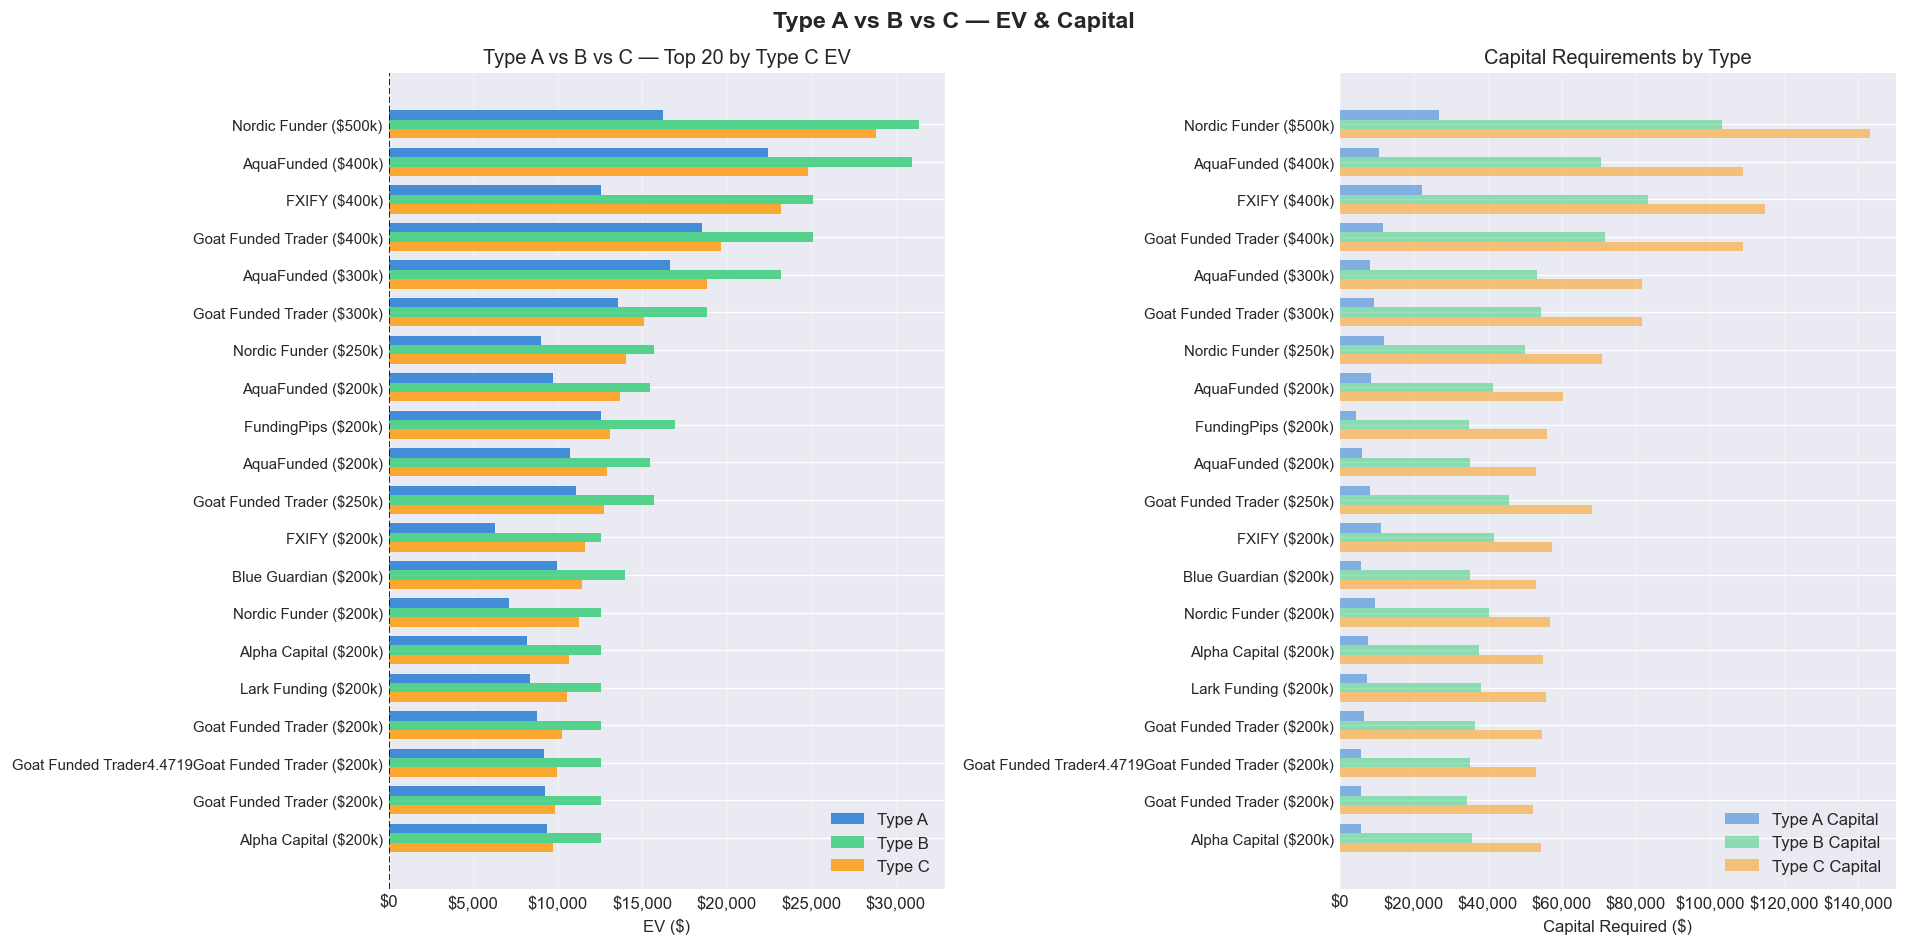

In [5]:
# Build comparison DataFrame
df_comp = pd.DataFrame({
    "firm": df_c["firm"],
    "account_size": df_c["account_size"],
    "dd_category": df_c["dd_category"],
    "type_a_ev": df_c["type_a_ev"],
    "type_b_ev": df_b["ev"],
    "type_c_ev": df_c["ev"],
    "surplus_value": df_c["expected_surplus"],
    "extra_drag_c_vs_b": df_c["total_drag"] - df_b["total_drag"],
    "cap_a": [r["challenge_cost"] / r["dd_max_pct"] / 100 +
              r["challenge_cost"] / r["dd_max_pct"] * r["dd_max_pct"] * 1.5
              for r in [compute_type_a_cost(c) for c in challenges]],
    "cap_b": df_b["capital_required"],
    "cap_c": df_c["capital_required"],
})

# Top 20 by Type C EV
top20 = df_comp.nlargest(20, "type_c_ev").sort_values("type_c_ev", ascending=True).copy()
top20["label"] = top20.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left: EV comparison
y = np.arange(len(top20))
h = 0.25

ax1.barh(y + h, top20["type_a_ev"], h, label="Type A", color="#1976d2", alpha=0.8)
ax1.barh(y, top20["type_b_ev"], h, label="Type B", color="#2ecc71", alpha=0.8)
ax1.barh(y - h, top20["type_c_ev"], h, label="Type C", color="#ff9800", alpha=0.8)

ax1.set_yticks(y)
ax1.set_yticklabels(top20["label"], fontsize=9)
ax1.axvline(x=0, color="black", linewidth=1, linestyle="--")
ax1.set_xlabel("EV ($)")
ax1.set_title("Type A vs B vs C — Top 20 by Type C EV")
ax1.legend(loc="lower right")
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(axis='x', alpha=0.3)

# Right: capital comparison
ax2.barh(y + h, top20["cap_a"], h, label="Type A Capital", color="#1976d2", alpha=0.5)
ax2.barh(y, top20["cap_b"], h, label="Type B Capital", color="#2ecc71", alpha=0.5)
ax2.barh(y - h, top20["cap_c"], h, label="Type C Capital", color="#ff9800", alpha=0.5)

ax2.set_yticks(y)
ax2.set_yticklabels(top20["label"], fontsize=9)
ax2.set_xlabel("Capital Required ($)")
ax2.set_title("Capital Requirements by Type")
ax2.legend(loc="lower right")
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(axis='x', alpha=0.3)

plt.suptitle("Type A vs B vs C — EV & Capital", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5 — Funded Phase Walkthrough (Single Challenge)

In [6]:
best_idx = df_c["ev"].idxmax()
best_c = results_c[best_idx]
best_b = results_b[best_idx]

print(f"Challenge: {best_c['firm']} — ${best_c['account_size']:,}")
print(f"Challenge cost: ${best_c['challenge_cost']:,.2f}")
print(f"Surplus target: ${best_c['surplus_target']:,.2f}")
print(f"")
print(f"  Type A EV:  ${best_c['type_a_ev']:,.2f}")
print(f"  Type B EV:  ${best_b['ev']:,.2f}")
print(f"  Type C EV:  ${best_c['ev']:,.2f}")
print(f"  C vs A:     ${best_c['ev_vs_type_a']:+,.2f}")
print(f"  C vs B:     ${best_c['ev'] - best_b['ev']:+,.2f}")
print()

df_cyc = pd.DataFrame(best_c["cycles"])
df_cyc.style.format({
    "prob_alive": "{:.1%}",
    "insured_stack": "${:,.2f}",
    "surplus_target": "${:,.0f}",
    "hedge_total_cover": "${:,.2f}",
    "hedge_size": "${:,.0f}",
    "withdrawal": "${:,.2f}",
    "exp_withdrawal": "${:,.2f}",
    "drag": "${:,.2f}",
    "exp_drag": "${:,.2f}",
    "prob_fail": "{:.1%}",
    "exp_surplus": "${:,.2f}",
    "capital": "${:,.0f}",
}).set_caption(f"Type C Cycle Detail — {best_c['firm']} ${best_c['account_size']:,}")

Challenge: Nordic Funder — $500,000
Challenge cost: $15,735.88
Surplus target: $10,000.00

  Type A EV:  $16,264.12
  Type B EV:  $31,358.88
  Type C EV:  $28,848.82
  C vs A:     $+12,584.70
  C vs B:     $-2,510.06



,cycle,prob_alive,insured_stack,surplus_target,hedge_total_cover,hedge_size,withdrawal,exp_withdrawal,drag,exp_drag,prob_fail,exp_surplus,capital
0,1,100.0%,"$15,735.88","$10,000","$25,735.88","$514,718","$16,000.00","$16,000.00","$12,266.18","$12,266.18",20.0%,"$2,000.00","$64,604"
1,2,80.0%,"$28,002.06","$10,000","$38,002.06","$760,041","$16,000.00","$12,800.00","$10,178.37","$8,142.70",16.0%,"$1,600.00","$81,907"
2,3,64.0%,"$38,180.43","$10,000","$48,180.43","$963,609","$16,000.00","$10,240.00","$9,464.36","$6,057.19",12.8%,"$1,280.00","$97,996"
3,4,51.2%,"$47,644.79","$10,000","$57,644.79","$1,152,896","$16,000.00","$8,192.00","$9,074.15","$4,645.96",10.2%,"$1,024.00","$113,422"
4,5,41.0%,"$56,718.94","$10,000","$66,718.94","$1,334,379","$16,000.00","$6,553.60","$8,822.31","$3,613.62",8.2%,$819.20,"$128,420"
5,6,32.8%,"$65,541.25","$10,000","$75,541.25","$1,510,825","$16,000.00","$5,242.88","$8,644.32","$2,832.57",6.6%,$655.36,"$143,115"


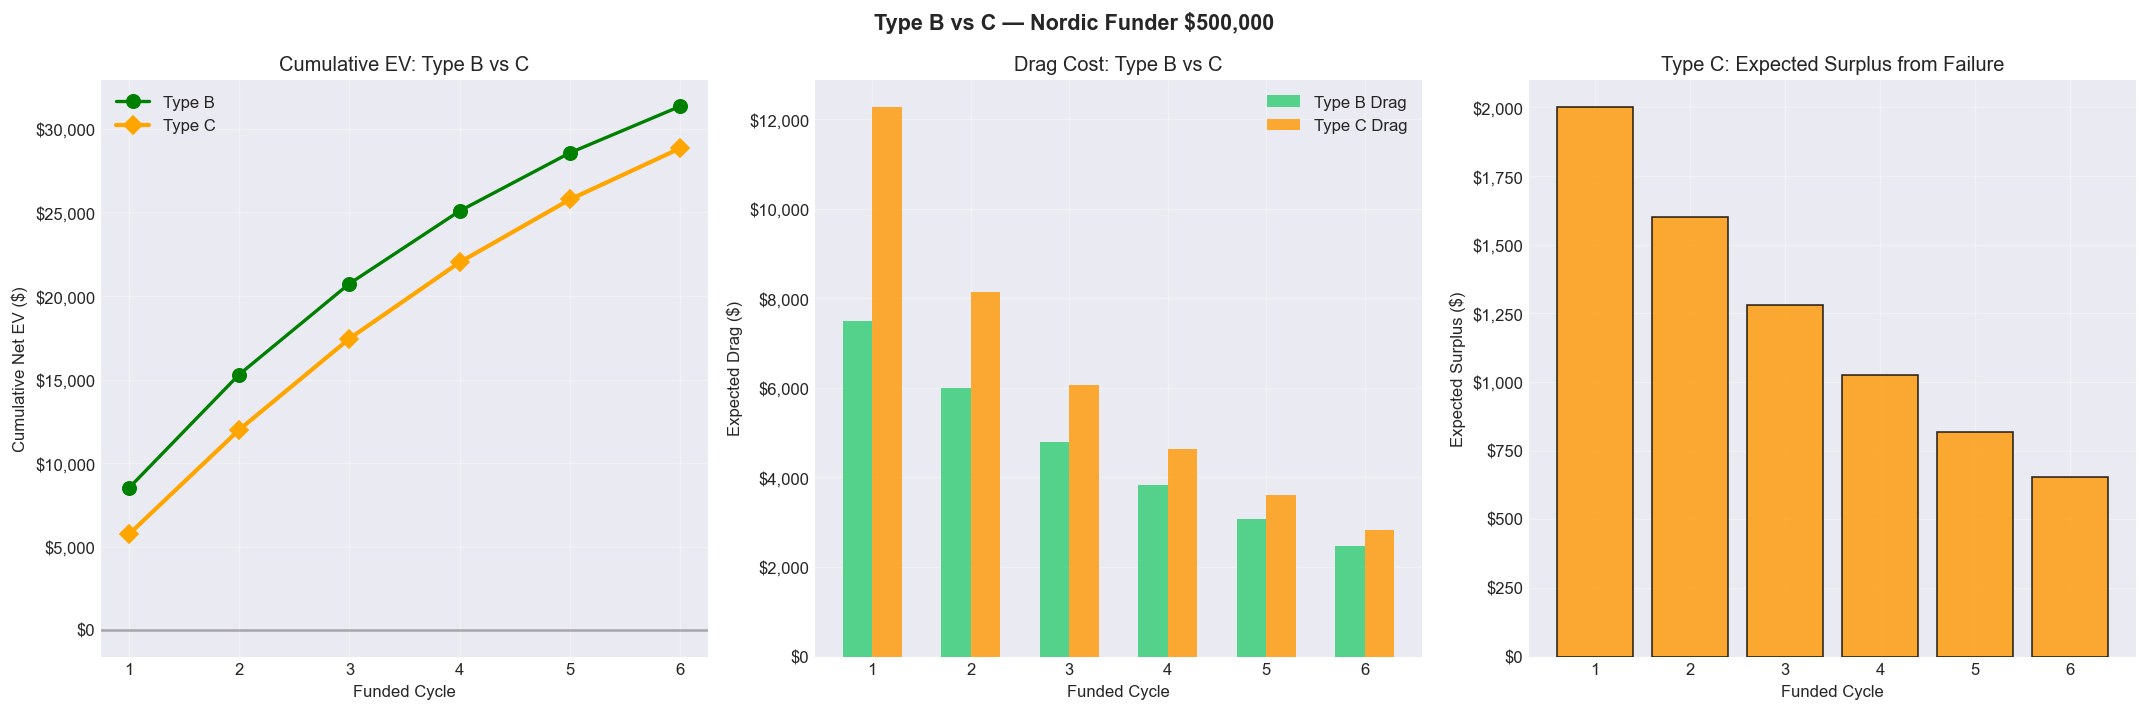

In [7]:
# Compare Type B and C funded phases side by side
cyc_b = best_b["cycles"]
cyc_c = best_c["cycles"]
nums = [c["cycle"] for c in cyc_c]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Cumulative net (withdrawals - drag)
cum_net_b = np.cumsum([c["exp_withdrawal"] - c["exp_drag"] for c in cyc_b])
cum_net_c = np.cumsum([c["exp_withdrawal"] - c["exp_drag"] + c["exp_surplus"] for c in cyc_c])

axes[0].plot(nums, cum_net_b, 'g-o', linewidth=2, markersize=8, label="Type B")
axes[0].plot(nums, cum_net_c, 'orange', marker='D', linewidth=2.5, markersize=8, label="Type C")
axes[0].axhline(y=0, color="black", linestyle="-", alpha=0.3)
axes[0].set_xlabel("Funded Cycle")
axes[0].set_ylabel("Cumulative Net EV ($)")
axes[0].set_title("Cumulative EV: Type B vs C")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# Panel 2: Drag comparison
drag_b = [c["exp_drag"] for c in cyc_b]
drag_c = [c["exp_drag"] for c in cyc_c]
x = np.arange(len(nums))
axes[1].bar(x - 0.15, drag_b, 0.3, label="Type B Drag", color="#2ecc71", alpha=0.8)
axes[1].bar(x + 0.15, drag_c, 0.3, label="Type C Drag", color="#ff9800", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(nums)
axes[1].set_xlabel("Funded Cycle")
axes[1].set_ylabel("Expected Drag ($)")
axes[1].set_title("Drag Cost: Type B vs C")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(alpha=0.3)

# Panel 3: Expected surplus from failure
surplus_vals = [c["exp_surplus"] for c in cyc_c]
axes[2].bar(nums, surplus_vals, color="#ff9800", alpha=0.8, edgecolor="black")
axes[2].set_xlabel("Funded Cycle")
axes[2].set_ylabel("Expected Surplus ($)")
axes[2].set_title("Type C: Expected Surplus from Failure")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(alpha=0.3)

plt.suptitle(f"Type B vs C — {best_c['firm']} ${best_c['account_size']:,}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Surplus Target Sensitivity

How does the desired surplus percentage affect EV and capital?

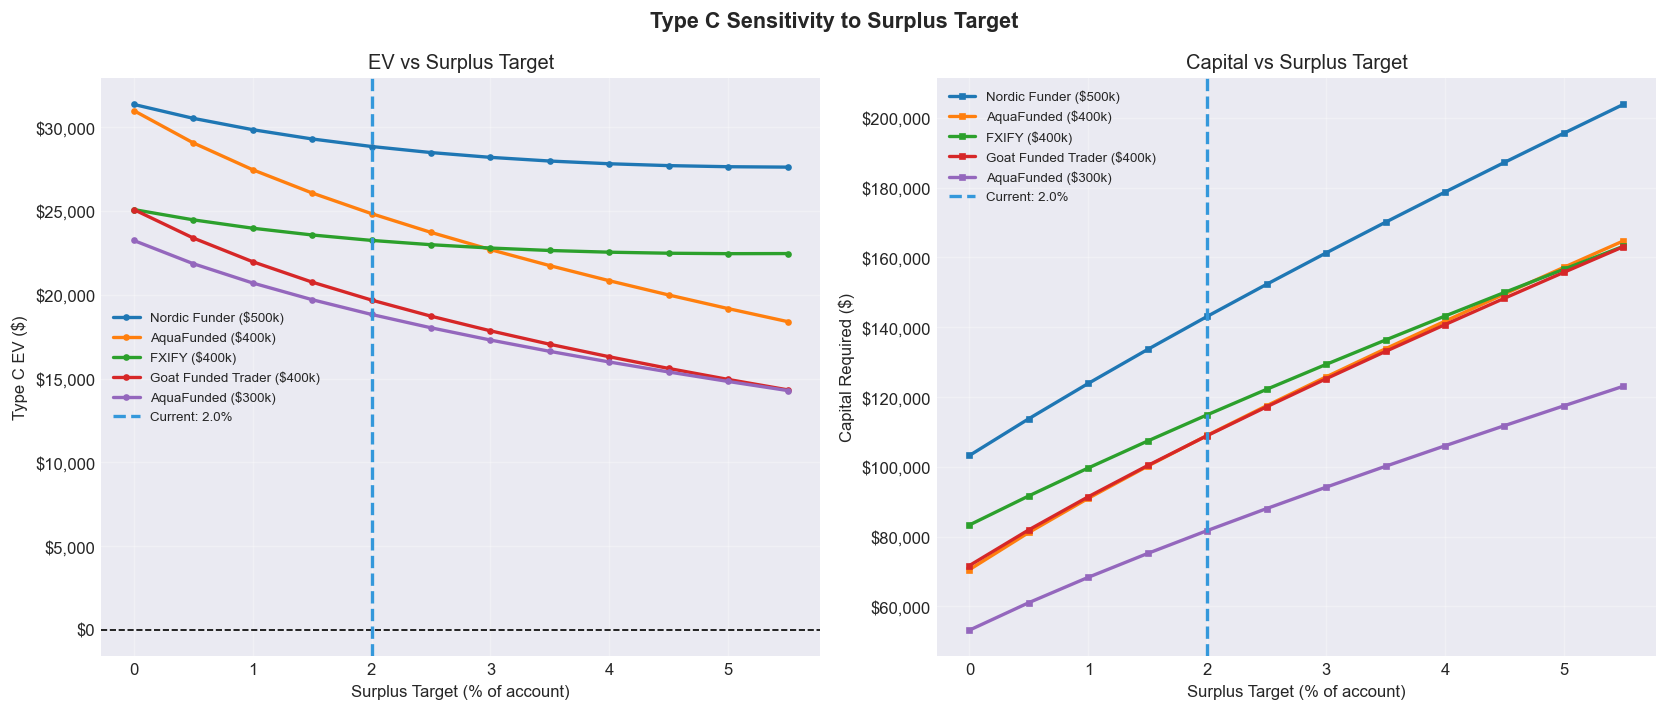

In [8]:
top5_idx = df_c.nlargest(5, "ev").index.tolist()
top5_ch = [challenges[i] for i in top5_idx]

surplus_sweep = np.arange(0, 0.06, 0.005)  # 0% to 5.5%

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_ch):
    evs = [compute_type_bc(ch, surplus_target_pct=sp)["ev"] for sp in surplus_sweep]
    caps = [compute_type_bc(ch, surplus_target_pct=sp)["capital_required"] for sp in surplus_sweep]
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"

    ax1.plot(surplus_sweep * 100, evs, marker='o', markersize=3,
             label=label, linewidth=2, color=colors[i % 10])
    ax2.plot(surplus_sweep * 100, caps, marker='s', markersize=3,
             label=label, linewidth=2, color=colors[i % 10])

ax1.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax1.axvline(x=SURPLUS_TARGET_PCT * 100, color="#3498db", linewidth=2, linestyle="--",
            label=f"Current: {SURPLUS_TARGET_PCT*100:.1f}%")
ax1.set_xlabel("Surplus Target (% of account)")
ax1.set_ylabel("Type C EV ($)")
ax1.set_title("EV vs Surplus Target")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

ax2.axvline(x=SURPLUS_TARGET_PCT * 100, color="#3498db", linewidth=2, linestyle="--",
            label=f"Current: {SURPLUS_TARGET_PCT*100:.1f}%")
ax2.set_xlabel("Surplus Target (% of account)")
ax2.set_ylabel("Capital Required ($)")
ax2.set_title("Capital vs Surplus Target")
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle("Type C Sensitivity to Surplus Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 — All Three Types Summary Table

In [9]:
summary = pd.DataFrame({
    "firm": df_c["firm"],
    "size": df_c["account_size"],
    "dd": df_c["dd_category"],
    "fee": df_c["fee"],
    "EV_A": df_c["type_a_ev"],
    "EV_B": df_b["ev"],
    "EV_C": df_c["ev"],
    "B_vs_A": df_b["ev"] - df_c["type_a_ev"],
    "C_vs_B": df_c["ev"] - df_b["ev"],
    "Cap_A": [r["challenge_cost"] / r["dd_max_pct"] / 100 +
              r["challenge_cost"] / r["dd_max_pct"] * r["dd_max_pct"] * 1.5
              for r in [compute_type_a_cost(c) for c in challenges]],
    "Cap_C": df_c["capital_required"],
})

summary.sort_values("EV_C", ascending=False).head(20).style.format({
    "fee": "${:,.0f}",
    "size": "${:,}",
    "EV_A": "${:,.0f}",
    "EV_B": "${:,.0f}",
    "EV_C": "${:,.0f}",
    "B_vs_A": "${:+,.0f}",
    "C_vs_B": "${:+,.0f}",
    "Cap_A": "${:,.0f}",
    "Cap_C": "${:,.0f}",
}).bar(subset=["EV_C"], color="#ff9800").bar(
    subset=["EV_B"], color="#2ecc71"
).bar(subset=["EV_A"], color="#1976d2").set_caption(
    "Top 20 — All Three Hedge Types Compared"
)

,firm,size,dd,fee,EV_A,EV_B,EV_C,B_vs_A,C_vs_B,Cap_A,Cap_C
151,Nordic Funder,"$500,000",static,"$1,932","$16,264","$31,359","$28,849","$+15,095","$-2,510","$26,751","$143,115"
216,AquaFunded,"$400,000",static,"$2,699","$22,475","$30,990","$24,843","$+8,515","$-6,147","$10,541","$109,017"
158,FXIFY,"$400,000",static,"$1,599","$12,576","$25,087","$23,247","$+12,511","$-1,840","$22,140","$114,910"
200,Goat Funded Trader,"$400,000",static,"$2,998","$18,575","$25,087","$19,688","$+6,512","$-5,399","$11,709","$108,946"
217,AquaFunded,"$300,000",static,"$2,099","$16,681","$23,242","$18,831","$+6,561","$-4,412","$8,198","$81,728"
199,Goat Funded Trader,"$300,000",static,"$2,398","$13,581","$18,815","$15,090","$+5,235","$-3,725","$9,366","$81,748"
150,Nordic Funder,"$250,000",static,$858,"$9,016","$15,679","$14,043","$+6,664","$-1,637","$11,873","$70,776"
218,AquaFunded,"$200,000",static,"$1,265","$9,736","$15,495","$13,687","$+5,759","$-1,808","$8,550","$60,352"
184,FundingPips,"$200,000",static,$998,"$12,593","$16,971","$13,128","$+4,377","$-3,843","$4,432","$55,928"
123,AquaFunded,"$200,000",static,$677,"$10,725","$15,495","$12,948","$+4,770","$-2,547","$5,972","$53,125"


## 8 — Type C Summary

### What Type C tells you

- The failure event itself becomes a profit centre, not just a recovery mechanism.
- Hedge is oversized: $S = (L + P) / DD$ — more drag, but failure pays out surplus.
- EV_C = funded withdrawals + expected surplus − total drag.
- The surplus target is tuneable — higher surplus = more drag = more capital.

### When to use Type C

- You have enough capital to absorb the larger hedge
- You want to monetise the downside (failure becomes a deliberate payoff)
- You're comfortable with higher operational complexity and drag

### Tradeoffs vs Type B

| | Type B | Type C |
|---|---|---|
| Failure outcome | Recovers stack (break even) | Recovers stack + surplus |
| Ongoing drag | Lower | Higher |
| Capital | Lower | Higher |
| Best for | Capital-conscious traders | Traders who want failure to pay |

### Limitations

- Higher drag erodes funded-phase profits faster
- Capital requirement scales with surplus target
- Operationally more fragile — the hedge must be precisely sized
- Trailing DD challenges become extremely expensive under Type C

---

**See also:**
- [Type A notebook](type_a_challenge_insurance.ipynb) — Challenge-only model
- [Type B notebook](type_b_funded_recovery.ipynb) — Funded recovery model
- [hedging-explained.md](../Product/hedging-explained.md) — Full knowledge base